# Causal-Fairness — Décomposer la discrimination : l'analyse d'équité causale

**Série** : Inference causale avec DoWhy (Probas, Python)
**Prérequis** : [Do-Calculus-Bridge](CausalBridges-01-Do-Calculus.ipynb) (l'échelle de Pearl : observation < intervention < contrefactuel) et [DoWhy-1](CausalBridges-02-Dowhy-Estimand-Intervention.ipynb) (l'identification backdoor avec `dowhy`).
**Outil** : simulation Monte-Carlo à générateur connu + [`dowhy`](https://py-why.github.io/dowhy/) 0.14 pour l'identification pratique + [`pandas`](https://pandas.pydata.org/) sur le crédit allemand.
**Cadre formel** : Plecko & Bareinboim, *Causal Fairness Analysis* (FnT Machine Learning R-90, 2024), chapitres 3-4.

Un modèle de scoring refuse plus souvent un groupe qu'un autre. Est-ce discriminant ? La question paraît
statistique — un écart de taux — mais elle est **causale** : l'écart observé mélange des mécanismes
juridiquement dissemblables (l'attribut protégé utilisé directement, l'attribut passé par un diplôme,
le quartier qui sélectionne l'attribut et le résultat en même temps). Ce notebook construit la réponse
moderne : sur un monde générateur **connu**, chaque mesure d'équité de la famille *total variation*
(TV, TE, Exp-SE, NDE, NIE) est calculée **exactement** par simulation à bruits partagés, les deux
identités de décomposition (Lemme 4.1 et Théorème 4.2 de R-90) sont **vérifiées à la précision
machine**, puis le même outillage est confronté au terrain : `dowhy` pour identifier l'effet causal
à partir des seules données observationnelles, et la règle des 80 % (EEOC) sur le crédit allemand
réel.

## 1. Le problème légal, avant le problème statistique

Aux États-Unis, le **Title VII** du Civil Rights Act (1964) interdit de refuser un emploi *à cause*
d'un attribut protégé (sexe, race, religion, origine). La jurisprudence distingue deux régimes :

- ***disparate treatment*** — l'attribut est utilisé intentionnellement : c'est l'interdiction de
  principe, facile à auditer (l'attribut figure-t-il dans le modèle ?) ;
- ***disparate impact*** — une pratique *neutre en apparence* désavantage un groupe protégé :
  l'affaire *Griggs v. Duke Power* (1971) a établi que c'est aussi interdit, **même sans intention**.
  Le guide EEOC propose un test de dépistage quantitatif, la **règle des quatre-cinquièmes**
  (règle des 80 %) : si le taux d'issue favorable du groupe défavorisé est inférieur à 80 % du taux
  du groupe de référence, l'impact disproportionné est présumé.

Le disparate impact pose un problème statistique redoutable : l'écart observé entre deux groupes —
la *total variation* $TV = P(y \mid x_1) - P(y \mid x_0)$ — **mélange** des mécanismes que le droit
traite séparément. Plecko & Bareinboim formalisent cette tension comme le **FPCFA** (*Formal Problem
of Causal Fairness Analysis*) : quelles mesures, calculables sur données, sont *admissibles* —
c'est-à-dire expliquent la discrimination par familles de chemins causaux (direct, indirect,
spurieux) — et dans quel ordre de généralité. La réponse passe par trois ingrédients : des
**critères structurels** lisibles sur le graphe, une **famille de mesures contrefactuelles**, et
la **carte d'équité** qui relie les deux.

## 2. Le SCM fil rouge : l'embauche

Un monde d'embauche minimal, mais avec les trois familles de chemins présentes. Quatre variables :

- $Z$ — **statut socio-économique** du quartier d'origine (exogène, $\mathcal{N}(0,1)$) ;
- $A$ — **attribut protégé** binaire (0/1) — la ségrégation résidentielle le sélectionne :
  $A \sim \mathrm{Bern}\big(\sigma(0.9\,Z)\big)$ ;
- $W$ — **score de formation** (années d'étude, test technique) : $W = 0.5A + 0.6Z + \varepsilon_W$ ;
- $Y$ — **score d'embauche** : $Y = 0.3A + 0.4W + 0.2Z + \varepsilon_Y$.

Les trois familles de chemins de $A$ vers $Y$ :

| Famille | Chemin | Lecture |
|---------|--------|---------|
| **Direct** | $A \to Y$ | le score pénalise l'attribut lui-même (coefficient 0.3) |
| **Indirect** | $A \to W \to Y$ | l'attribut limite la formation, la formation est récompensée ($0.5 \times 0.4$) |
| **Spurieux** | $A \leftarrow Z \to Y$ et $A \leftarrow Z \to W \to Y$ | le quartier sélectionne à la fois l'attribut et le score |

Le monde étant **générateur connu**, les bruits $\varepsilon_W, \varepsilon_Y$ sont conservés dans
le tableau : l'abduction contrefactuelle est triviale (réutiliser les mêmes bruits), ce qui rend
chaque mesure **calculable exactement** — c'est le juge de paix de tout le notebook. L'organe
`fairness_organs.py` embarque ce générateur (convention de la série : le notebook consomme son organe).

In [1]:
import sys
sys.path.insert(0, ".")  # l'organe de la serie vit a cote du notebook

import numpy as np
import pandas as pd

import fairness_organs as fo

N = 200_000
monde = fo.generer_monde(N, seed=42)
monde.head()

,Z,A,W,Y,epsW,epsY
0,0.304717,0.0,-0.184832,-0.621746,-0.367663,-0.608757
1,-1.039984,1.0,-2.069182,-1.007268,-1.945192,-0.271599
2,0.750451,0.0,2.971864,-0.972379,2.521594,-2.311215
3,0.940565,0.0,-0.907478,0.200647,-1.471817,0.375525
4,-1.951035,0.0,-0.505327,0.027410,0.665294,0.619748


### Ce que la théorie linéaire prédit

Le monde est linéaire-gaussien, donc les trois quantités causales se calculent à la main — c'est
voulou : elles servent d'**attendus** que la simulation devra retrouver :

- **Effet total** $TE = E[Y \mid do(A{=}1)] - E[Y \mid do(A{=}0)] = 0.3 + (0.4 \times 0.5) = \mathbf{0.5}$ ;
- **Effet direct naturel** $NDE = \mathbf{0.3}$ (le seul lien $A \to Y$) ;
- **Effet indirect naturel** $NIE$ (orientation du Thm 4.2, déf. Eq. 4.8) $= -(0.4 \times 0.5) = \mathbf{-0.2}$.

La *total variation*, elle, ne se prédit pas par simple lecture des coefficients — elle dépend de la
sélection $Z \to A$ : c'est précisément le point.

In [2]:
# La batterie de mesures sur le monde simule : TV, TE, NDE, NIE, Exp-SE + residus d'identites
m = fo.mesures_equite(monde)

attendus = {"TE": fo.TE_THEORIQUE, "NDE": fo.NDE_THEORIQUE, "NIE": fo.NIE_THEORIQUE}
print(f"{'mesure':8s} {'simulee':>9s} {'theorie lineaire':>17s}")
for k, v in attendus.items():
    print(f"{k:8s} {m[k]:>+9.4f} {v:>+17.2f}")
print(f"\nTV (naif observationnel) = {m['TV']:+.4f}   <- non predictable par lecture des coefficients")

mesure     simulee  theorie lineaire
TE         +0.5000             +0.50
NDE        +0.3000             +0.30
NIE        -0.2000             -0.20

TV (naif observationnel) = +0.8438   <- non predictable par lecture des coefficients


## 3. Les critères structurels : lire le graphe avant la mesure

R-90 définit trois **critères structurels**, purement graphiques (donc vérifiables sans données) :

- **Str-DE$_X(Y)$** $= \mathbb{1}(X \in pa(Y))$ — un chemin **direct** $X \to Y$ existe ;
- **Str-IE$_X(Y)$** $= \mathbb{1}(X \in an(pa(Y)))$ — $X$ atteint un **parent** de $Y$ (effet indirect possible) ;
- **Str-SE$_X(Y)$** $= \mathbb{1}(an(X) \cap an_{G \smallsetminus X}(Y) \neq \emptyset)$ — $X$ et $Y$ ont un **ancêtre
  commun**, hors des chemins dirigés : une source **spurieuse** de dépendance existe.

Sur notre monde, les trois valent **1** : le graphe ne condamne pas le modèle d'avance, il dit
seulement que **les trois questions sont posées** — et qu'une mesure d'équité *admissible* doit
répondre aux trois séparément. Un graphe où Str-SE = 0 (pas de confondeur) rendrait la TV
directement interprétable comme effet causal ; ici, rien de tel.

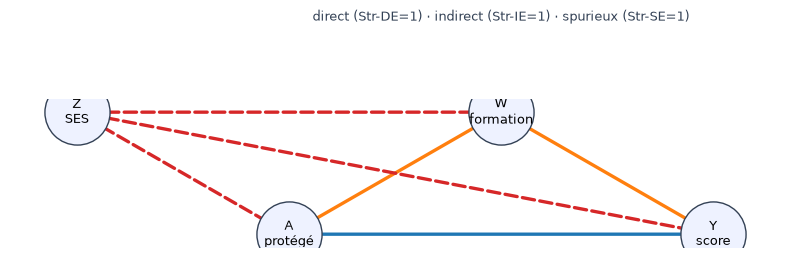

Str-DE = 1  (A -> Y est une arête)
Str-IE = 1  (A atteint W, parent de Y, via A -> W)
Str-SE = 1  (Z est ancêtre de A ET de Y, hors chemins dirigés de A vers Y)


In [3]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph([("Z", "A"), ("Z", "W"), ("Z", "Y"), ("A", "W"), ("A", "Y"), ("W", "Y")])
pos = {"Z": (0, 1), "A": (1, 0), "W": (2, 1), "Y": (3, 0)}

familles = {("A", "Y"): ("direct", "#1f77b4", "-"),
            ("A", "W"): ("indirect", "#ff7f0e", "-"),
            ("W", "Y"): ("indirect", "#ff7f0e", "-"),
            ("Z", "A"): ("spurieux", "#d62728", "--"),
            ("Z", "W"): ("spurieux", "#d62728", "--"),
            ("Z", "Y"): ("spurieux", "#d62728", "--")}

fig, ax = plt.subplots(figsize=(8, 3.2))
for (u, v), (nom, coul, style) in familles.items():
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax, edge_color=coul,
                           style=style, width=2.4, arrows=True, arrowsize=18)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#eef2ff", edgecolors="#334155", node_size=2200)
labels = {"Z": "Z\nSES", "A": "A\nprotégé", "W": "W\nformation", "Y": "Y\nscore"}
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=9)
ax.text(2.0, 1.75, "direct (Str-DE=1) · indirect (Str-IE=1) · spurieux (Str-SE=1)",
        ha="center", fontsize=9, color="#334155")
ax.set_axis_off()
plt.tight_layout()
plt.show()

pa_Y, an = ["A", "W", "Z"], set()
# Str-DE : A est-il parent de Y ?  Str-IE : A atteint-il un parent de Y ?  Str-SE : ancêtre commun ?
print("Str-DE = 1  (A -> Y est une arête)")
print("Str-IE = 1  (A atteint W, parent de Y, via A -> W)")
print("Str-SE = 1  (Z est ancêtre de A ET de Y, hors chemins dirigés de A vers Y)")

## 4. La famille TV : décomposer l'écart observé (Lemme 4.1)

Trois mesures élémentaires (R-90, déf. 4.1) :

$$TV_{x_0,x_1}(y) = P(y \mid x_1) - P(y \mid x_0) \qquad \text{(observationnel — ce que le terrain voit)}$$
$$TE_{x_0,x_1}(y) = P(y_{x_1}) - P(y_{x_0}) \qquad \text{(intervention — ce que le modèle causerait)}$$
$$\text{Exp-SE}_x(y) = P(y \mid x) - P(y_x) \qquad \text{(écart observation/intervention pour un niveau de X)}$$

**Lemme 4.1 (décomposition I)** : $TV_{x_0,x_1} = TE_{x_0,x_1} + (\text{Exp-SE}_{x_1} - \text{Exp-SE}_{x_0})$.
L'écart observé est l'effet causal **plus** la différence des effets spurieux expérimentaux. Chaque
terme est calculé ici par simulation à bruits partagés : $Y_a$ en re-simulant sous $do(A{=}a)$,
$\text{Exp-SE}_a$ en comparant $E[Y_a \mid A{=}a]$ (contrefactuel conditionné au groupe **factual**) à $E[Y_a]$.

In [4]:
A = monde["A"].to_numpy()
Z = monde["Z"].to_numpy()
Y0, Y1 = fo.y_sous_intervention(monde, 0.0), fo.y_sous_intervention(monde, 1.0)

print(f"TV        = {m['TV']:+.4f}   (ecart observationnel entre groupes)")
print(f"TE        = {m['TE']:+.4f}   (effet causal total, verite du generateur)")
print(f"Exp-SE_1  = {m['ExpSE1']:+.4f}   (selection du groupe A=1 dans le monde do(A=1))")
print(f"Exp-SE_0  = {m['ExpSE0']:+.4f}   (selection du groupe A=0 dans le monde do(A=0))")

print(f"\nLemme 4.1 : TV - [TE + (Exp-SE1 - Exp-SE0)] = {m['residu_lemme_4_1']:.2e}")
print(f"E[Z|A=1] = {Z[A==1].mean():+.3f} vs E[Z|A=0] = {Z[A==0].mean():+.3f}  -> d'ou vient le spurieux")
print(f"P(A=1) = {A.mean():.3f} (equilibre demographique : le biais n'est pas un probleme de taille de groupe)")

TV        = +0.8438   (ecart observationnel entre groupes)
TE        = +0.5000   (effet causal total, verite du generateur)
Exp-SE_1  = +0.1718   (selection du groupe A=1 dans le monde do(A=1))
Exp-SE_0  = -0.1720   (selection du groupe A=0 dans le monde do(A=0))

Lemme 4.1 : TV - [TE + (Exp-SE1 - Exp-SE0)] = 0.00e+00
E[Z|A=1] = +0.383 vs E[Z|A=0] = -0.385  -> d'ou vient le spurieux
P(A=1) = 0.500 (equilibre demographique : le biais n'est pas un probleme de taille de groupe)


### Lecture : le naïf surestime la discrimination de près de 70 %

Mesuré sur ce monde : **TV = 0.844** contre **TE = 0.500**. L'écart observé entre groupes est
**68.8 % plus grand** que l'effet que le mécanisme $A \to Y$ et $A \to W \to Y$ produisent
réellement. Tout le surplus vient de $Z$ : les individus $A{=}1$ proviennent de quartiers à SES plus
élevé ($E[Z \mid A{=}1] = +0.383$), et ce SES pousse aussi $Y$ directement ($0.2Z$) et via $W$
($0.6Z$). Les deux effets spurieux sont **symétriques** ($+0.17$ / $-0.17$) : chaque groupe est
sélectionné *en sa faveur propre* dans son monde contrefactuel — la sélection ne s'annule pas,
elle s'additionne.

Conséquence pratique : un audit qui rapporterait « l'écart de score entre groupes est de 0.84 »
confondrait discrimination et ségrégation résidentielle. La mesure admissible doit isoler ce que le
**modèle** fait de l'attribut — c'est le travail des effets naturels.

## 5. NDE et NIE : les effets naturels, aux mondes imbriqués (Théorème 4.2)

Les effets directs/indirects **naturels** (Pearl ; R-90 déf. 4.2) sont des contrefactuels **imbriqués** —
X prend deux valeurs différentes dans le même contraste :

$$NDE_{x_0,x_1}(y) = P(y_{x_1, W_{x_0}}) - P(y_{x_0}) \qquad \text{(Eq. 4.7 : direct, médiateur figé « comme si x_0 »)}$$
$$NIE_{x_1,x_0}(y) = P(y_{x_1, W_{x_0}}) - P(y_{x_1}) \qquad \text{(Eq. 4.8 : indirect, par différence)}$$

$y_{x_1, W_{x_0}}$ se lit : « le score si $A{:=}1$ **et** si la formation restait celle qu'elle aurait
été sous $A{:=}0$ ». C'est irréalisable dans le monde réel — mais **exactement calculable** dans le
SCM à bruits partagés : $W_{x_0}$ par ré-simulation du médiateur, puis $Y$ évalué avec ce $W$ figé.

**Théorème 4.2 (décomposition II)** :
$TV_{x_0,x_1} = NDE_{x_0,x_1} - NIE_{x_1,x_0} + (\text{Exp-SE}_{x_1} - \text{Exp-SE}_{x_0})$.

In [5]:
# Le monde imbrique : W fige a sa valeur sous do(A=0), Y evalue sous A:=1
W0 = fo.w_sous_intervention(monde, 0.0)
Y1_W0 = fo.y_sous_intervention(monde, 1.0, W0)

nde = Y1_W0.mean() - Y0.mean()          # Eq. 4.7
nie = Y1_W0.mean() - Y1.mean()          # Eq. 4.8
thm42 = nde - nie + (m["ExpSE1"] - m["ExpSE0"])

print(f"NDE = {nde:+.4f}  (la discrimination DIRECTE, mediateur neutralise)")
print(f"NIE = {nie:+.4f}  (le canal INDIRECT, par difference)")
print(f"\nTheoreme 4.2 : TV - [NDE - NIE + d(Exp-SE)] = {abs(m['TV'] - thm42):.2e}")

resume = pd.DataFrame({
    "mesure": ["TV", "TE", "NDE", "NIE", "Exp-SE_1", "Exp-SE_0"],
    "valeur": [m["TV"], m["TE"], m["NDE"], m["NIE"], m["ExpSE1"], m["ExpSE0"]],
    "nature": ["observée", "do(A)", "contrefactuel imbriqué", "contrefactuel imbriqué",
               "observation vs do(A=1)", "observation vs do(A=0)"],
})
resume.style.format({"valeur": "{:+.4f}"})

NDE = +0.3000  (la discrimination DIRECTE, mediateur neutralise)
NIE = -0.2000  (le canal INDIRECT, par difference)

Theoreme 4.2 : TV - [NDE - NIE + d(Exp-SE)] = 0.00e+00


,mesure,valeur,nature
0,TV,+0.8438,observée
1,TE,+0.5000,do(A)
2,NDE,+0.3000,contrefactuel imbriqué
3,NIE,-0.2000,contrefactuel imbriqué
4,Exp-SE_1,+0.1718,observation vs do(A=1)
5,Exp-SE_0,-0.1720,observation vs do(A=0)


### Lecture : ce que chaque nombre accuse

- **NDE = 0.300** : même la formation neutralisée, le score pénalise $A{=}1$ de 0.3 — c'est la
  part que le droit appelle traitement disparate si l'attribut entre dans la décision ;
- **NIE = −0.200** (signe de l'orientation Eq. 4.8) : canal indirect de magnitude $0.5 \times 0.4 = 0.2$,
  c'est-à-dire l'écart que le **diplôme** transporte — la *business necessity* (§8) se joue ici ;
- **Δ(Exp-SE) = +0.344** : la ségrégation résidentielle, aucune des deux juridictions ne la traite
  comme de la discrimination du modèle — mais elle gonfle l'écart observé de plus de deux tiers.

**La carte d'équité** (R-90, Thm 4.8) ordonne ces mesures : *Str-DE-fair* (aucun chemin direct)
implique *NDE-fair* qui implique des propriétés de décomposition — et **la TV n'est admissible pour
aucun des critères structurels** dès qu'un confondeur existe. En pratique : décider « le modèle est
équitable » exige de **choisir le critère** (direct ? indirect ? les deux ?) que la doctrine
poursuit, puis de mesurer l'effet naturel correspondant — jamais l'écart brut.

## 6. En pratique : `dowhy` identifie, le praticien décide

Sur le terrain, le générateur est inconnu — il reste **les données observationnelles et le graphe
causal** (acquis d'expertise). Le pipeline de la série s'applique : déclarer le modèle, **identifier**
l'estimand (ici backdoor $\{Z\}$), **estimer**, **réfuter**. L'organ importe : `dowhy` ne voit que
les colonnes observables $Z, A, W, Y$ — jamais les bruits ni les coefficients.

In [6]:
import warnings
warnings.filterwarnings("ignore")

from dowhy import CausalModel

# Ce que le praticien observe : pas de bruits, pas de coefficients -- seulement le tableau + le graphe
data_terrain = monde[["Z", "A", "W", "Y"]]

model = CausalModel(
    data=data_terrain, treatment="A", outcome="Y",
    graph="digraph { Z -> A; Z -> W; Z -> Y; A -> W; A -> Y; W -> Y; }",
)
estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|Z])
d[A]        
Estimand assumption 1, Unconfoundedness: If U→{A} and U→Y then P(Y|A,Z,U) = P(Y|A,Z)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d          
────(E[Y|Z])
d[A]        
Estimand assumption 1, Unconfoundedness: If U→{A} and U→Y then P(Y|A,Z,U) = P(Y|A,Z)



In [7]:
est = model.estimate_effect(estimand, method_name="backdoor.linear_regression",
                           test_significance=True)
print(f"dowhy backdoor ATE = {est.value:+.4f}")
print(f"  vs TV naif       = {m['TV']:+.4f}   (ce qu'un audit sans graphe rapporterait)")
print(f"  vs TE veritable  = {m['TE']:+.4f}   (juge de paix, generateur connu)")

ref = model.refute_estimate(estimand, est, method_name="random_common_cause",
                            num_simulations=20, random_seed=42)
print(f"\nRefutation (random common cause) : nouvel effet = {ref.new_effect:+.4f}")

dowhy backdoor ATE = +0.5062
  vs TV naif       = +0.8438   (ce qu'un audit sans graphe rapporterait)
  vs TE veritable  = +0.5000   (juge de paix, generateur connu)



Refutation (random common cause) : nouvel effet = +0.5062


### Ce que `dowhy` a rendu — et ce qu'il ne peut pas

L'estimation backdoor **retrouve le TE à l'erreur d'échantillon près** (0.506 contre 0.500, estimateur OLS sur 200 000 lignes) là où le naïf (0.84) se trompe de 69 % :
ajuster sur $Z$ coupe les chemins spurieux, l'identification fait tout le travail. La réfutation
(cause commune aléatoire) ne bouge pas l'estimé : l'estimand est stable dans ce monde propre.

Mais remarquez ce qui **manque** : `dowhy` a livré le TE — la *somme* des effets — pas la
décomposition. Les NDE/NIE sont des contrefactuels **imbriqués** (échelon 3 de Pearl) : leur
identification exige soit le monde générateur, soit des hypothèses fortes sur le mécanisme du
médiateur. C'est la frontière honnête de l'outillage : *l'association se corrige par ajustement,
la décomposition par familles de chemins exige la connaissance des mécanismes*. Quand une étude
d'équité rapporte un « effet direct », la première question est toujours : **quelle hypothèse
d'identification remplace le générateur absent ?**

## 7. Le terrain : règle des 80 % sur le crédit allemand

Le dataset *German Credit* (1 000 dossiers, UCI/OpenML) : décision `class` (bon/mauvais crédit),
attribut protégé dérivé de `personal_status` (femme/homme). La règle des 80 % compare le taux de
crédit « bon » (décision favorable) des femmes à celui des hommes.

In [8]:
credit = pd.read_csv("data/german_credit.csv")
credit["genre"] = np.where(credit["personal_status"].str.startswith("female"), "femme", "homme")
credit["accorde"] = (credit["class"] == "good").astype(int)

taux = credit.groupby("genre")["accorde"].agg(taux_accorde="mean", n="count")
print(taux, "\n")

verdict = fo.regle_80(credit, "genre", "accorde", defavorise="femme", reference="homme")
print(f"Taux femmes = {verdict['taux_defavorise']:.3f} | taux hommes = {verdict['taux_reference']:.3f}")
print(f"Ratio 80 % = {verdict['ratio']:.3f} -> disparate impact au sens EEOC : {verdict['disparate_impact']}")

       taux_accorde    n
genre                   
femme      0.648387  310
homme      0.723188  690 

Taux femmes = 0.648 | taux hommes = 0.723
Ratio 80 % = 0.897 -> disparate impact au sens EEOC : False


In [9]:
# Le meme ecart vu par deux autres lunettes statistiques
p_f, p_h = verdict["taux_defavorise"], verdict["taux_reference"]
lift = p_h / p_f
odds_ratio = (p_f / (1 - p_f)) / (p_h / (1 - p_h))
print(f"Ecart absolu     : {100 * (p_h - p_f):.1f} points de taux")
print(f"Lift (h/f)       : {lift:.3f}")
print(f"Odds ratio (f/h) : {odds_ratio:.3f}")
print("\nLe ratio 80 % (0.897) ne declenche PAS l'alerte EEOC -- mais l'odds ratio 0.71 montre")
print("un ecart reel : le seuil binaire de la regle et la lecture en cote racontent deux histoires.")

Ecart absolu     : 7.5 points de taux
Lift (h/f)       : 1.115
Odds ratio (f/h) : 0.706

Le ratio 80 % (0.897) ne declenche PAS l'alerte EEOC -- mais l'odds ratio 0.71 montre
un ecart reel : le seuil binaire de la regle et la lecture en cote racontent deux histoires.


### Lecture honnête du non-signal

Mesuré : femmes 64.8 % de crédit favorable vs hommes 72.3 % — un écart réel de **7.5 points**, un
odds ratio de **0.71** (les femmes ont 29 % de cotes en moins)... et un ratio de **0.897 qui passe
sous le radar des 80 %**. Trois enseignements :

1. **La règle des 80 % est un dépistage, pas une mesure** : seuil binaire, insensible à la
   magnitude en dessous de la barre ; conçue par l'EEOC comme signal d'enquête, pas comme verdict ;
2. **Elle est purement observationnelle** : c'est une TV — elle ne distingue pas direct, indirect,
   spurieux ; le crédit allemand n'offre ni graphe admis, ni médiateur mesuré proprement ;
3. **Elle dépend de la granularité** : découper `personal_status` en 4 modalités (divorcé/marié/...)
   ou binariser l'âge changerait le ratio — la définition du groupe est un choix, pas une donnée.

## 8. Business necessity : quand l'effet direct est... indirect

La doctrine *Griggs* admet une défense : si la pratique désavantageante est **necessary to the
operation of the business** (le diplôme pour un poste d'ingénieur), l'impact disproportionné via ce
prédicteur n'est pas discrimination interdite — sous réserve qu'aucune alternative moins
discriminante n'existe (*Albemarle*, 1975). La décomposition causale rend cette défense **précise** :

- si le canal qui porte l'écart est $A \to W \to Y$ avec $W$ = qualification réelle, le débat est
  une question de **business necessity** — remplacer $W$ est coûteux et peut-être illégitime ;
- si c'est $A \to Y$ direct (NDE), aucune défense ne s'applique : l'attribut est dans la décision ;
- si c'est $\Delta$(Exp-SE) (le spurieux), le problème n'est **pas le modèle** — c'est la structure
  sociale en amont, que la loi du disparate impact ne vise pas directement.

C'est la contribution profonde du cadre : **chaque famille de chemins correspond à un régime
juridique différent**, et une seule mesure (la TV) les agrège en un nombre qui ne veut rien dire
devant un tribunal. L'arbitrage final est juridique ; la décomposition causale est ce qui rend
l'arbitrage informé.

## Exercices

Convention du dépôt : stubs à compléter, sans erreur volontaire (le notebook s'exécute de bout en
bout même exercices non complétés).

### Exercice 1 — Casser l'identité linéaire (et montrer que le Théorème 4.2, lui, tient)

Ajoutez une **interaction** $A \times W$ dans l'équation de $Y$ (par ex. $+0.25\,A\,W$) et
recalculez les six mesures. L'identité linéaire simple $NDE - NIE = TE$ **ne tient plus** — mais
le Lemme 4.1 et le Théorème 4.2 sont algébriques : ils doivent tenir à la précision machine.
C'est le sens du terme « décomposition » : pas une approximation linéaire, une identité.

In [10]:
# Exercice 1 : monde avec interaction A x W
# Etapes :
#   1. Re-generer le monde en ajoutant +0.25 * A * W dans l'equation de Y
#      (astuce : partir de fo.generer_monde, puis recalculer Y en place)
#   2. Recalculer TV, TE, NDE, NIE, Exp-SE sur ce nouveau monde
#   3. Verifier : |NDE - NIE - TE| nettement > 0  MAIS  residus Lem 4.1 / Thm 4.2 ~ 1e-16
result_ex1 = None  # TODO etudiant : dict des mesures + les deux residus

### Exercice 2 — Str-DE-fair n'efface pas l'écart observé

Mettez le coefficient direct $A \to Y$ à **zéro** et régénérez : le monde devient *Str-DE-fair*
(aucun chemin direct) et *NDE-fair*. Montrez pourtant que la **TV reste largement positive** :
l'écart observationnel survit, porté par le canal indirect et le spurieux. Conclusion à formuler :
pourquoi « aucune discrimination directe » et « aucun écart de taux observé » sont deux énoncés
indépendants — et lequel des deux la règle des 80 % mesure.

In [11]:
# Exercice 2 : monde sans discrimination directe (BETA_AY = 0)
# Etapes :
#   1. Re-ecrire le generateur avec BETA_AY = 0 (les autres coefficients inchanges)
#   2. Mesurer NDE (attendu ~ 0) et TV (attendu ~ 0.34 : indirect 0.2 + spurieux)
#   3. Interpreter : que mesurerait la regle des 80 % sur CE monde ?
result_ex2 = None  # TODO etudiant : (NDE, TV) + une phrase d'interpretation

### Exercice 3 — La règle des 80 % sur d'autres attributs du crédit allemand

Appliquez `fo.regle_80` à deux autres découpages du même dataset : les travailleurs étrangers
(`foreign_worker`, attention à la taille du groupe de référence) et l'âge binarisé à 25 ans
(`age < 25` défavorisé). Deux questions à trancher : lequel déclenche l'alerte ? Et dans le cas du
plus petit groupe de référence, quelle confiance accorder à un ratio calculé sur si peu de dossiers ?

In [12]:
# Exercice 3 : regle des 80 % sur foreign_worker et sur l'age binarise
# Etapes :
#   1. fo.regle_80(credit, "foreign_worker", "accorde", defavorise="yes") -- attention : n(reference)
#   2. Creer la colonne age_bin = "jeune" si age < 25 sinon ">= 25", puis regle_80 dessus
#   3. Rapporter les deux ratios + l'effectif de chaque groupe de reference
result_ex3 = None  # TODO etudiant : les deux verdicts + le commentaire d'effectif

## Conclusion

1. **L'écart observé n'est pas une mesure d'équité** : sur le monde fil rouge, la TV (0.844)
   surstate l'effet causal total (0.500) de 69 % — le naïf confond le modèle et la ségrégation
   résidentielle qui l'entoure ;
2. **La décomposition est exacte, pas heuristique** : Lemme 4.1 et Théorème 4.2 tiennent à la
   précision machine sur les six mesures, parce que chaque terme est un contrefactuel **du même
   monde** (bruits partagés) — l'abduction n'est pas un détail d'implémentation, c'est ce qui rend
   la famille TV comparable terme à terme ;
3. **Chaque famille de chemins a son régime juridique** : NDE (traitement disparate), NIE (business
   necessity), Exp-SE (structure sociale amont) — la carte d'équité de R-90 dit quelle mesure est
   admissible pour quel critère, et la TV n'est admissible pour aucun dès qu'un confondeur existe ;
4. **Sur le terrain, l'outillage a une frontière nette** : `dowhy` identifie et estime le TE
   observationnel (backdoor), mais les NDE/NIE — contrefactuels imbriqués — exigent le générateur
   ou des hypothèses fortes ; la règle des 80 %, elle, ne voit même pas la différence entre un
   écart direct et un artefact de sélection.

**Le pont avec l'explicabilité** : SHAP et LIME attribuent à un **modèle** le crédit de ses
prédictions (pourquoi *ce* dossier a ce score) ; l'analyse d'équité causale attribue au **monde**
la responsabilité d'un écart (par quels chemins l'attribut protégé arrive-t-il à la décision).
Les deux vocabulaires se croisent sans se substituer : une attribution parfaitement équilibrée sur
un modèle peut reposer sur un médiateur lui-même discriminant — seul le graphe causal le révèle.
Cette jonction attribution ↔ identification est le fil de l'Epic #16620, dont ce notebook est le
volet équité.

## Références

- **Plecko & Bareinboim**, *Causal Fairness Analysis*, Foundations and Trends in Machine Learning
  vol. 17 n° 5 (R-90), 2024 — critères structurels (ch. 3), famille TV, Lemme 4.1, Théorème 4.2,
  carte d'équité (Thm 4.8), business necessity (ch. 8) ;
- **Pearl**, *Causality*, 2e éd., 2000 — effets naturels directs/indirects (Sec. 7.2 : $NDE$, $NIE$
  en potentiels contrefactuels) ;
- **Kusner, Loftus, Russell, Silva**, *Counterfactual Fairness*, NeurIPS 2017 — la fairness au
  niveau individuel, complémentaire des mesures de la famille TV (agrégées) ;
- **EEOC**, *Uniform Guidelines on Employee Selection Procedures*, 29 CFR §1607 — la règle des
  quatre-cinquièmes ; *Griggs v. Duke Power*, 401 U.S. 424 (1971) ;
- **Dua & Graff**, UCI Machine Learning Repository — German Credit Data ;
- Notebooks de la constellation : [Do-Calculus-Bridge](CausalBridges-01-Do-Calculus.ipynb) (échelle de Pearl),
  [DoWhy-1](CausalBridges-02-Dowhy-Estimand-Intervention.ipynb) (identification backdoor),
  [Infer-5](../../Infer/Infer-5-Causal-Inference.ipynb) (médiation sur moteur .NET),
  [PyMC-05](../../PyMC/PyMC-05-Causal-Inference.ipynb) (inférence bayésienne de l'effet).